# Comparing two versions of EoMT
One trained on the Cityscapes dataset, another one on the COCO

## Setup

In [1]:
###########################################################
# Run this cell only if you run the notebook on the Colab #
###########################################################

import os

repo_url = "https://github.com/timmfy/MaskArchitectureAnomaly_CourseProject.git"
repo_dir = "/content/MaskArchitectureAnomaly_CourseProject"

if not os.path.exists(repo_dir):
    !git clone {repo_url} {repo_dir}

%cd /content/MaskArchitectureAnomaly_CourseProject

# Install the libraries
!pip install -r requirements.txt

# Mount the drive with the model weights and the cityscapes validation dataset
from google.colab import drive
drive.mount('/content/drive')

/content/MaskArchitectureAnomaly_CourseProject
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
################################
# Change the paths accordingly #
################################

dataset_path = "/content/drive/MyDrive/FAI_Project/CityScapesDataset"
finetuned_models_path = "/content/drive/MyDrive/FAI_Project/checkpoints/"
pretrained_models_path = "/content/drive/MyDrive/CourseProjectAnomaly/"

In [3]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np

# Add root and eomt to path
root_path = os.path.abspath(".")
if root_path not in sys.path:
    sys.path.insert(0, root_path)

import eomt_setup
import eomt_inference

device = eomt_setup.setup_environment(eomt_path="eomt")

img_idx = 0 # Visualize the first image in the dataset
config_path_cityscapes = "eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
config_path_coco = "eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
config_path_coco_interpolated = "eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x_finetuning.yaml"
weights_path_cityscapes_pretrained = pretrained_models_path + "eomt_cityscapes.bin"
weights_path_coco_pretrained = pretrained_models_path + "eomt_coco.bin"
weights_path_coco_finetuned_backbone_frozen = finetuned_models_path + "backbone_frozen_24_epochs.ckpt"
weights_path_coco_finetuned_backbone_unfrozen = finetuned_models_path + "backbone_unfrozen_10_50_epochs.ckpt"
weights_path_coco_finetuned_backbone_unfrozen_interpolated = finetuned_models_path + "backbone_unfrozen_interpolation_10_45_epochs.ckpt"

IGNORE_INDEX = 255

## 1. CityScapes EoMT (Semantic Segmentation)
First, we load the model trained on CityScapes and run semantic inference.

Loading Cityscapes Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading checkpoint from /content/drive/MyDrive/CourseProjectAnomaly/eomt_cityscapes.bin with weights_only=True
Loaded weights from /content/drive/MyDrive/CourseProjectAnomaly/eomt_cityscapes.bin


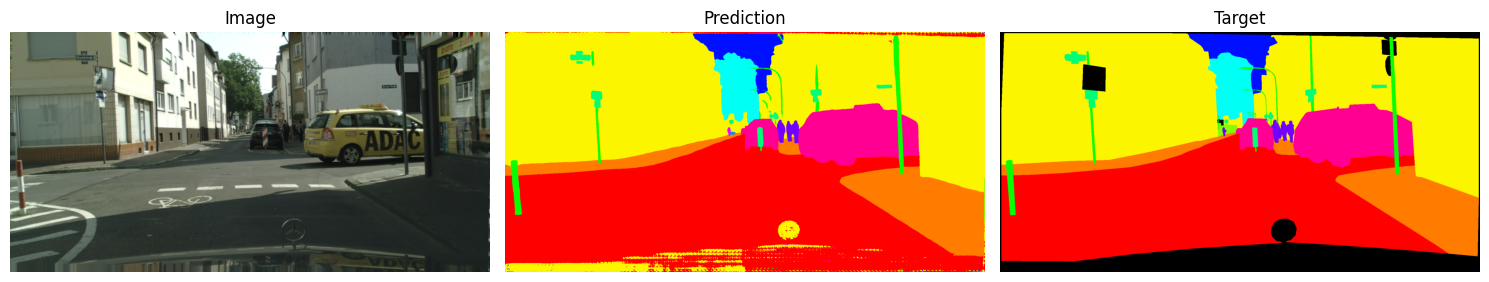

In [4]:
print("Loading Cityscapes Model...")
config_cs = eomt_setup.load_config(config_path_cityscapes)
data_cs = eomt_setup.setup_data(config_cs, data_path=dataset_path)
model_cs = eomt_setup.load_model(config_cs, data_cs, device, weights_path=weights_path_cityscapes_pretrained)

img, target = data_cs.val_dataloader().dataset[img_idx]
pred_array, target_array = eomt_inference.infer_semantic(model_cs, img, target, device, data_cs.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, pred_array, target_array, IGNORE_INDEX)

## 2. COCO EoMT (Panoptic Segmentation)
Next, we load the model trained on COCO and run panoptic inference.
Note: This model can also perform semantic inference.

Loading COCO Model...


Loading checkpoint from /content/drive/MyDrive/CourseProjectAnomaly/eomt_coco.bin with weights_only=True
Loaded weights from /content/drive/MyDrive/CourseProjectAnomaly/eomt_coco.bin


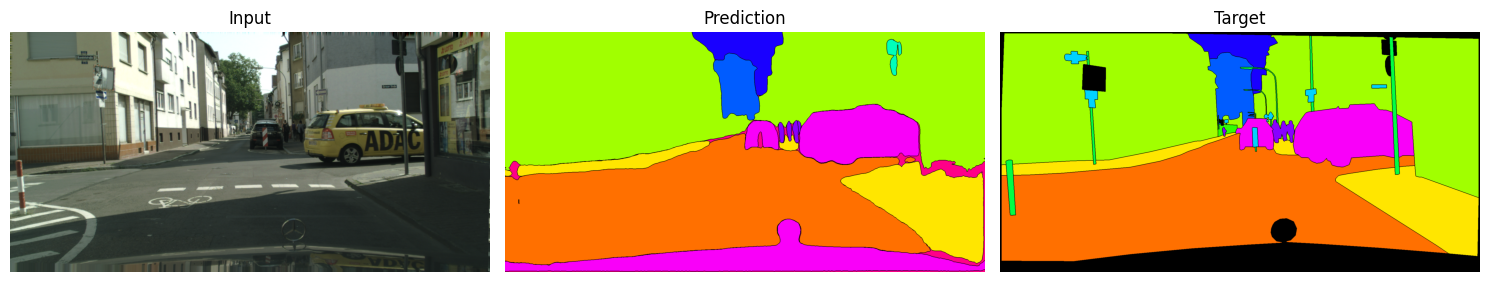

In [5]:
import importlib
importlib.reload(eomt_setup)
importlib.reload(eomt_inference)

print("Loading COCO Model...")
config_coco = eomt_setup.load_config(config_path_coco)
data_coco = eomt_setup.setup_data(config_coco, data_path=dataset_path)

cpu_device = torch.device("cpu")
model_coco = eomt_setup.load_model(config_coco, data_coco, cpu_device, weights_path=weights_path_coco_pretrained)
model_coco = model_coco.to(device=device, dtype=torch.float32)

img, target = data_coco.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = eomt_inference.infer_panoptic(model_coco, img, target, device)
# Map COCO semantic predictions to Cityscapes train IDs for color consistency
sem_pred = eomt_inference.map_coco_preds_to_cityscapes(sem_pred)
eomt_inference.plot_panoptic_results(model_coco, img, sem_pred, inst_pred, sem_target, inst_target)

## 3. COCO EoMT (Semantic Segmentation)
Running semantic inference with the COCO model on the same Cityscapes image.

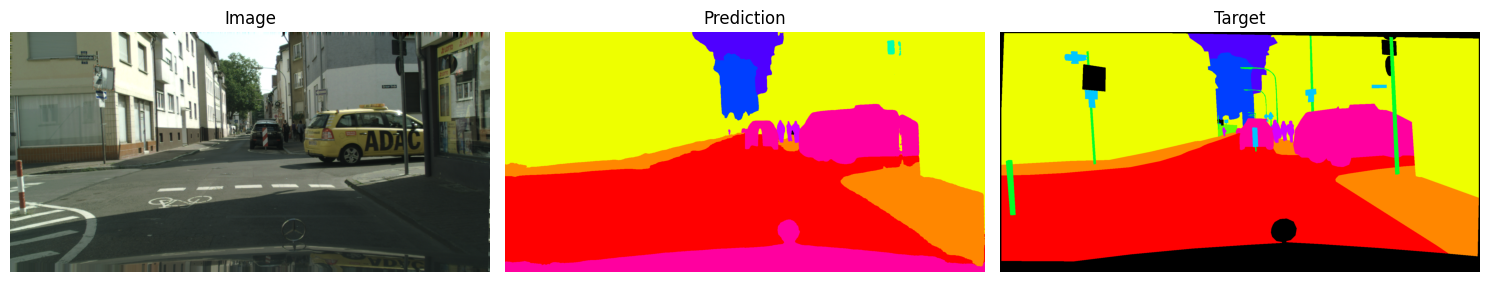

In [6]:
img, target = data_coco.val_dataloader().dataset[img_idx]
sem_pred, sem_target = eomt_inference.infer_semantic(model_coco, img, target, device, data_coco.img_size, IGNORE_INDEX)
sem_pred = eomt_inference.map_coco_preds_to_cityscapes(sem_pred)
eomt_inference.plot_semantic_results(img, sem_pred, sem_target, IGNORE_INDEX)

## 4. ERFNet (Semantic Segmentation)

## ERFNet Evaluation

In [7]:
import torch
import os
from erfnet import ERFNet
from erfEvaluation import evaluate_erfnet_cityscapes, get_cityscapes_dataloader

CITYSCAPES_ROOT = "./data/cityscapes"
WEIGHTS_PATH = "./erfnet_pretrained.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 19
BATCH_SIZE = 4

model = ERFNet(num_classes=NUM_CLASSES)

if os.path.exists(WEIGHTS_PATH):
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))

model = model.to(DEVICE)

dataloader = get_cityscapes_dataloader(CITYSCAPES_ROOT, batch_size=BATCH_SIZE)

mIoU, ious = evaluate_erfnet_cityscapes(model, dataloader, DEVICE, num_classes=NUM_CLASSES)

for i, iou in enumerate(ious):
    print(f"Class {i} IoU: {iou.item():.4f}")
print(f"Mean IoU (mIoU): {mIoU.item():.4f}")

Using device: cuda
Loading Cityscapes dataset from: /content/drive/MyDrive/FAI_Project/CityScapesDataset
Dataset loaded successfully. Validation images: 500
Initializing ERFNet model...
Model weights loaded successfully from: /content/MaskArchitectureAnomaly_CourseProject/trained_models/erfnet_pretrained.pth
Starting evaluation loop...


Evaluating: 100%|██████████| 125/125 [04:21<00:00,  2.09s/it]


EVALUATION RESULTS
Mean IoU (mIoU): 0.5410
----------------------------------------
Per-class IoU:
Class 00: 0.8931
Class 01: 0.6890
Class 02: 0.8092
Class 03: 0.2365
Class 04: 0.3424
Class 05: 0.5500
Class 06: 0.4156
Class 07: 0.6150
Class 08: 0.8564
Class 09: 0.5065
Class 10: 0.6858
Class 11: 0.7138
Class 12: 0.3645
Class 13: 0.8643
Class 14: 0.2580
Class 15: 0.4615
Class 16: 0.0891
Class 17: 0.2901
Class 18: 0.6383


## 4. Evaluation of the pretrained models on the validation dataset

In [8]:
print(f"Evaluating the COCO model...")
coco_mIoU, coco_ious = eomt_inference.evaluate_semantic(model_coco, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=255, is_coco=True)

Evaluating the COCO model...


In [9]:
print(f"Evaluating the CityScapes model...")
cityscapes_mIoU, cityscapes_ious = eomt_inference.evaluate_semantic(model_cs, data_cs.val_dataloader(), device, data_cs.img_size, num_classes=19, ignore_index=255, is_coco=False)

Evaluating the CityScapes model...


KeyboardInterrupt: 

In [ ]:
print("CityScapes Results:")
print(f"mIoU: {cityscapes_mIoU}")
print(f"IoUs: {cityscapes_ious}")
print("COCO Results:")
print(f"mIoU: {coco_mIoU}")
print(f"IoUs: {coco_ious}")

## 5. Visual Comparison of Finetuned Models
Now we visualize the predictions of the three

### 5.1 Finetuned with the Backbone Frozen
We load the models and run inference on a sample image from the Cityscapes validation set.

In [ ]:
print("Visualizing Finetuned (Frozen Backbone)...")
config_frozen = eomt_setup.load_config(config_path_coco_interpolated)
data_coco = eomt_setup.setup_data(config_frozen, data_path=dataset_path)
model_frozen = eomt_setup.load_model(config_frozen, data_coco, device, weights_path=weights_path_coco_finetuned_backbone_frozen)

img, target = data_coco.val_dataloader().dataset[img_idx]
sem_pred_frozen, sem_target = eomt_inference.infer_semantic(model_frozen, img, target, device, data_coco.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, sem_pred_frozen, sem_target, IGNORE_INDEX)

### 5.2 Finetuned with the Backbone Unfrozen

In [ ]:
print("Visualizing Finetuned (Unfrozen Backbone)...")
config_unfrozen = eomt_setup.load_config(config_path_coco_interpolated)
data_coco = eomt_setup.setup_data(config_unfrozen, data_path=dataset_path)
model_unfrozen = eomt_setup.load_model(config_unfrozen, data_coco, device, weights_path=weights_path_coco_finetuned_backbone_unfrozen)

sem_pred_unfrozen, _ = eomt_inference.infer_semantic(model_unfrozen, img, target, device, data_coco.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, sem_pred_unfrozen, sem_target, IGNORE_INDEX)

### 5.3 Finetuned with the Backbone Unfrozen + Interpolation

In [ ]:
print("Visualizing Finetuned (Interpolated)...")
config_interp = eomt_setup.load_config(config_path_coco_interpolated)
data_coco = eomt_setup.setup_data(config_interp, data_path=dataset_path)
model_interp = eomt_setup.load_model(config_interp, data_coco, device, weights_path=weights_path_coco_finetuned_backbone_unfrozen_interpolated)

sem_pred_interp, _ = eomt_inference.infer_semantic(model_interp, img, target, device, data_coco.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, sem_pred_interp, sem_target, IGNORE_INDEX)

## 6. Evaluation of the finetuned models on the validation dataset

In [ ]:
print("Evaluating Finetuned Model (Backbone Frozen)...")
frozen_mIoU, frozen_ious = eomt_inference.evaluate_semantic(model_frozen, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=IGNORE_INDEX)
print(f"Frozen Backbone mIoU: {frozen_mIoU}")

In [ ]:
print(f"Frozen Backbone IoUs: {frozen_ious}")

In [ ]:
print("Evaluating Finetuned Model (Backbone Unfrozen)...")
unfrozen_mIoU, unfrozen_ious = eomt_inference.evaluate_semantic(model_unfrozen, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=IGNORE_INDEX)
print(f"Unfrozen Backbone mIoU: {unfrozen_mIoU}")
print(f"Unfrozen Backbone IoUs: {unfrozen_ious}")

In [ ]:
print("Evaluating Finetuned Model (Backbone Unfrozen + Interpolation)...")
interp_mIoU, interp_ious = eomt_inference.evaluate_semantic(model_interp, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=IGNORE_INDEX)
print(f"Interpolated Model mIoU: {interp_mIoU}")
print(f"Interpolated Model IoUs: {interp_ious}")